# Phase 2 — Domain-Level EDA

## Purpose

Explore the decomposed Credit Risk datasets from a business-domain perspective before implementing domain validation rules.

## Scope

This notebook covers:

- Customer Profile
- Financial History
- Loan Application
- Cross-domain relationships and consistency

The analysis is exploratory. Findings that represent meaningful data-quality expectations will later be converted into explicit validation rules and implemented separately.

## EDA Workflow

For each domain:

1. Load
2. Understand
3. Profile
4. Visualize
5. Investigate
6. Record findings

# CUSTOMER PROFILE
1. Schema
2. Missing values
3. Duplicates / identifiers
4. Numerical analysis
5. Categorical analysis
6. Anomaly investigation
7. Findings
8. Conclusion
        ↓
# FINANCIAL HISTORY
1. Schema
2. Missing values
3. Duplicates / identifiers
4. Numerical analysis
5. Categorical analysis
6. Anomaly investigation
7. Findings
8. Conclusion
        ↓
# LOAN APPLICATION
1. Schema
2. Missing values
3. Duplicates / identifiers
4. Numerical analysis
5. Categorical analysis
6. Anomaly investigation
7. Findings
8. Conclusion
        ↓
# CROSS-DOMAIN ANALYSIS
1. Customer relationships
2. Application relationships
3. Identifier consistency
4. Cross-domain consistency
5. Findings
        ↓
# FINAL EDA CONCLUSIONS

In [4]:
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path.cwd().parent

DATA_DIRECTORY = PROJECT_ROOT / "data" / "raw"

CUSTOMER_PATH = DATA_DIRECTORY / "customer" / "customer.csv"
FINANCIAL_HISTORY_PATH = DATA_DIRECTORY / "financial_history" / "financial_history.csv"
LOAN_APPLICATION_PATH = DATA_DIRECTORY / "loan_application" / "loan_application.csv"


customer_df = pd.read_csv(CUSTOMER_PATH)
financial_history_df = pd.read_csv(FINANCIAL_HISTORY_PATH)
loan_application_df = pd.read_csv(LOAN_APPLICATION_PATH)

In [2]:
print("Customer Profile")
print(customer_df.info())

print("\nFinancial History")
print(financial_history_df.info())

print("\nLoan Application")
print(loan_application_df.info())

Customer Profile
<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        32581 non-null  str    
 1   age                32581 non-null  int64  
 2   income             32581 non-null  int64  
 3   home_ownership     32581 non-null  str    
 4   employment_length  31686 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 1.2 MB
None

Financial History
<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   customer_id            32581 non-null  str  
 1   default_history        32581 non-null  str  
 2   credit_history_length  32581 non-null  int64
dtypes: int64(1), str(2)
memory usage: 763.7 KB
None

Loan Application
<class 'pandas.DataFrame'>
RangeIndex: 32581 entri

In [3]:
print("Customer Profile columns:")
print(customer_df.columns.tolist())

print("\nFinancial History columns:")
print(financial_history_df.columns.tolist())

print("\nLoan Application columns:")
print(loan_application_df.columns.tolist())

Customer Profile columns:
['customer_id', 'age', 'income', 'home_ownership', 'employment_length']

Financial History columns:
['customer_id', 'default_history', 'credit_history_length']

Loan Application columns:
['application_id', 'customer_id', 'loan_amount', 'loan_purpose', 'risk_grade', 'loan_interest_rate', 'loan_income_ratio', 'loan_outcome']


## 3. Customer Profile EDA

The Customer Profile domain contains demographic and income-related attributes associated with each technical customer identifier.

In [5]:
customer_df.head()

,customer_id,age,income,home_ownership,employment_length
0,C000001,22,59000,RENT,123.0
1,C000002,21,9600,OWN,5.0
2,C000003,25,9600,MORTGAGE,1.0
3,C000004,23,65500,RENT,4.0
4,C000005,24,54400,RENT,8.0


In [6]:
print("Shape:", customer_df.shape)

print("\nData types:")
print(customer_df.dtypes)

print("\nMissing values:")
print(customer_df.isna().sum())

print("\nDuplicate rows:", customer_df.duplicated().sum())

Shape: (32581, 5)

Data types:
customer_id              str
age                    int64
income                 int64
home_ownership           str
employment_length    float64
dtype: object

Missing values:
customer_id            0
age                    0
income                 0
home_ownership         0
employment_length    895
dtype: int64

Duplicate rows: 0


In [7]:
customer_df[["age", "income", "employment_length"]].describe()

,age,income,employment_length
count,32581.000000,3.258100e+04,31686.000000
mean,27.734600,6.607485e+04,4.789686
std,6.348078,6.198312e+04,4.142630
min,20.000000,4.000000e+03,0.000000
25%,23.000000,3.850000e+04,2.000000
50%,26.000000,5.500000e+04,4.000000
75%,30.000000,7.920000e+04,7.000000
max,144.000000,6.000000e+06,123.000000


<Axes: title={'center': 'Customer Age Distribution'}, xlabel='Age', ylabel='Frequency'>

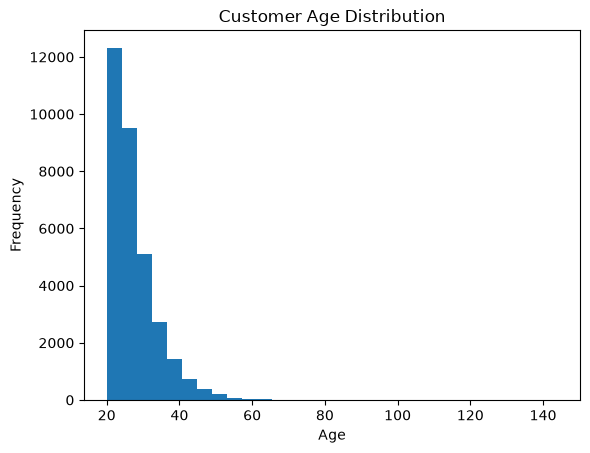

In [8]:
customer_df["age"].plot(
    kind="hist",
    bins=30,
    title="Customer Age Distribution",
    xlabel="Age",
    ylabel="Frequency",
)

### Age — EDA Findings

- `age` is concentrated strongly among younger customers, particularly between approximately 20 and 30 years.
- The distribution is strongly right-skewed, with frequency decreasing substantially as age increases.
- Very few observations occur at higher ages.
- The dataset contains extreme age values extending to 144 years.
- These extreme observations require domain validation before any decision is made to remove or correct them.
- No data-cleaning action is performed during EDA.

In [9]:
customer_df.loc[
    customer_df["age"] > 60,
    ["customer_id", "age"],
].sort_values("age", ascending=False)

,customer_id,age
81,C000082,144
183,C000184,144
32297,C032298,144
575,C000576,123
747,C000748,123
...,...,...
32477,C032478,61
32489,C032490,61
32498,C032499,61
32539,C032540,61


In [10]:
age_ranges = pd.cut(
    customer_df["age"],
    bins=[19, 30, 40, 50, 60, 100, float("inf")],
    labels=["20–30", "31–40", "41–50", "51–60", "61–100", "101+"],
)

age_ranges.value_counts().sort_index()

age
20–30     24824
31–40      6263
41–50      1206
51–60       218
61–100       65
101+          5
Name: count, dtype: int64

### Age — Distribution Findings

- The Customer Profile population is heavily concentrated in the 20–30 age range.
- The frequency of observations decreases substantially as age increases.
- Only 65 observations fall between 61 and 100 years.
- Five observations have ages above 100 years.
- The maximum observed age is 144 years.
- The extreme upper tail should be subject to an explicit business-domain validation rule.

In [11]:
customer_df.loc[
    customer_df["age"] > 100,
    ["customer_id", "age"],
].sort_values("age", ascending=False)

,customer_id,age
81,C000082,144
183,C000184,144
32297,C032298,144
575,C000576,123
747,C000748,123


In [12]:
customer_df.loc[
    customer_df["age"] > 100,
    ["customer_id", "age", "employment_length"],
].sort_values(["age", "employment_length"], ascending=[False, False])

,customer_id,age,employment_length
32297,C032298,144,12.0
81,C000082,144,4.0
183,C000184,144,4.0
747,C000748,123,7.0
575,C000576,123,2.0


In [13]:
customer_df["employment_length"].describe()

count    31686.000000
mean         4.789686
std          4.142630
min          0.000000
25%          2.000000
50%          4.000000
75%          7.000000
max        123.000000
Name: employment_length, dtype: float64

In [14]:
customer_df["employment_length"].value_counts(dropna=False).sort_index()

employment_length
0.0      4105
1.0      2915
2.0      3849
3.0      3456
4.0      2874
5.0      2946
6.0      2666
7.0      2196
8.0      1687
9.0      1367
10.0      696
11.0      740
12.0      575
13.0      426
14.0      335
15.0      238
16.0      165
17.0      129
18.0      104
19.0       64
20.0       42
21.0       38
22.0       19
23.0       10
24.0       10
25.0        8
26.0        6
27.0        5
28.0        3
29.0        1
30.0        2
31.0        4
34.0        1
38.0        1
41.0        1
123.0       2
NaN       895
Name: count, dtype: int64

In [15]:
customer_df.loc[
    customer_df["employment_length"] > 20,
    ["customer_id", "age", "employment_length"],
].sort_values("employment_length", ascending=False)

,customer_id,age,employment_length
0,C000001,22,123.0
210,C000211,21,123.0
32355,C032356,78,41.0
32515,C032516,53,38.0
32428,C032429,58,34.0
...,...,...,...
32067,C032068,37,21.0
32055,C032056,37,21.0
31892,C031893,39,21.0
31968,C031969,37,21.0


In [16]:
customer_df["estimated_start_age"] = customer_df["age"] - customer_df["employment_length"]

customer_df.loc[
    customer_df["employment_length"].notna() & (customer_df["estimated_start_age"] < 15),
    ["customer_id", "age", "employment_length", "estimated_start_age"],
].sort_values("estimated_start_age")

,customer_id,age,employment_length,estimated_start_age
210,C000211,21,123.0,-102.0
0,C000001,22,123.0,-101.0


### Employment Length — EDA Findings

* `employment_length` is concentrated primarily between 0 and 10 years.
* The dataset contains two observations with an `employment_length` of 123 years.
* These observations correspond to customers aged 21 and 22, producing impossible implied starting ages of -102 and -101 years.
* These two observations represent clear business-rule violations.
* Other long employment histories should not be rejected solely because of their magnitude; their plausibility depends on the customer's age.
* This suggests that validation should consider the relationship between `age` and `employment_length`, rather than relying only on an arbitrary maximum employment length.
* No data-cleaning action is performed during EDA.


## Customer Profile — EDA Findings

### Structure and identifiers

* The Customer Profile dataset contains 32,581 observations and 5 columns.
* `customer_id` is unique across the dataset and contains no missing values.
* No duplicate rows were identified.

### Missing values

* `employment_length` contains 895 missing observations.
* The remaining Customer Profile attributes contain no missing values.
* Missing-value treatment will be addressed during the later validation and preprocessing stages.

### Age

* `age` is strongly concentrated between approximately 20 and 30 years.
* The distribution is strongly right-skewed, with substantially fewer observations at higher ages.
* Five observations have ages above 100 years, with a maximum observed age of 144 years.
* These extreme values require explicit business-domain validation.
* No observations are removed or corrected during EDA.

### Income

* `income` ranges from 4,000 to 6,000,000.
* Most observations are concentrated at substantially lower income levels, while a small number of observations have very high income values.
* Extreme income values are not automatically considered errors because their validity depends on the business context.
* Income values should therefore be subject to domain validation rather than automatic outlier removal.

### Employment length

* `employment_length` is concentrated primarily between 0 and 10 years.
* Two observations contain an employment length of 123 years while the corresponding customers are aged 21 and 22.
* These observations produce impossible implied starting ages and represent clear business-rule violations.
* Other long employment histories should not be rejected solely because of their magnitude; their plausibility depends on the customer's age.
* Validation should therefore consider the relationship between `age` and `employment_length`.

### Home ownership

* `home_ownership` contains four observed categories: `RENT`, `MORTGAGE`, `OWN`, and `OTHER`.
* `RENT` and `MORTGAGE` represent the majority of observations.
* `OTHER` is a very small category compared with the other ownership types.
* No unexpected categorical values were identified.

### Overall findings

* The Customer Profile domain is structurally consistent, with unique technical identifiers and no duplicate rows.
* The principal data-quality concerns identified during EDA are missing employment length and extreme or potentially invalid values in age and employment length.
* Extreme income values require domain validation but should not be automatically removed as statistical outliers.
* The findings above will be translated into explicit validation rules during the Domain Validation stage.
* EDA does not modify the underlying datasets.


## Customer Profile — EDA Conclusion

The Customer Profile domain is structurally consistent and contains unique technical customer identifiers with no duplicate rows. The main data-quality observations are missing `employment_length`, extreme age values, and two clearly invalid employment-length observations that are incompatible with the corresponding customer ages.

The `income` distribution contains extreme values that require domain validation but should not be treated as errors solely because they are statistically unusual. Overall, the EDA findings provide several candidates for explicit validation rules, while no cleaning or modification is performed at this stage.

These findings will be revisited during the Domain Validation stage, where the relevant business and consistency rules will be implemented and tested explicitly.


# FINANCIAL HISTORY
## Step 1 — Schema

The Financial History dataset contains only three columns, so this should be quick.

In [17]:
print("Financial History — Schema")
print("=" * 35)

print("\nShape:")
print(financial_history_df.shape)

print("\nData types:")
print(financial_history_df.dtypes)

print("\nColumns:")
print(financial_history_df.columns.tolist())

Financial History — Schema

Shape:
(32581, 3)

Data types:
customer_id                str
default_history            str
credit_history_length    int64
dtype: object

Columns:
['customer_id', 'default_history', 'credit_history_length']


# Step 2 — Missing values

In [18]:
print("Financial History — Missing Values")
print("=" * 40)

missing_values = financial_history_df.isna().sum()
missing_percentage = financial_history_df.isna().mean() * 100

missing_summary = pd.DataFrame(
    {
        "missing_count": missing_values,
        "missing_percentage": missing_percentage,
    }
)

missing_summary

Financial History — Missing Values


,missing_count,missing_percentage
customer_id,0,0.0
default_history,0,0.0
credit_history_length,0,0.0


# Step 3 — Duplicates / identifiers

Here we only need to verify two things:

Whether there are duplicate rows.
Whether customer_id is unique, as expected for the relationship with Customer Profile.

In [19]:
print("Financial History — Duplicates / Identifiers")
print("=" * 50)

print("\nDuplicate rows:", financial_history_df.duplicated().sum())

print(
    "Duplicate customer_id values:",
    financial_history_df["customer_id"].duplicated().sum(),
)

print(
    "Unique customer_id values:",
    financial_history_df["customer_id"].nunique(),
)

Financial History — Duplicates / Identifiers

Duplicate rows: 0
Duplicate customer_id values: 0
Unique customer_id values: 32581


# Step 4 — Numerical analysis

There is only one numerical variable in this domain: credit_history_length.

In [20]:
financial_history_df["credit_history_length"].describe()

count    32581.000000
mean         5.804211
std          4.055001
min          2.000000
25%          3.000000
50%          4.000000
75%          8.000000
max         30.000000
Name: credit_history_length, dtype: float64

Step 4 — Numerical analysis is complete.

credit_history_length has:

32,581 non-missing observations
Minimum: 2 years
Median: 4 years
Mean: 5.80 years
75th percentile: 8 years
Maximum: 30 years

Nothing here by itself indicates an obvious data-quality problem. We'll let the categorical analysis and anomaly investigation determine whether anything deserves further attention.

# Step 5 — Categorical analysis

The categorical variable is default_history. We want to see:

Which values exist.
How frequently they occur.
Whether there are unexpected categories.

In [21]:
print("Financial History — Categorical Analysis")
print("=" * 45)

print("\nValue counts:")
print(financial_history_df["default_history"].value_counts())

print("\nValue counts (%):")
print(financial_history_df["default_history"].value_counts(normalize=True).mul(100).round(2))

print("\nUnique values:")
print(financial_history_df["default_history"].unique())

Financial History — Categorical Analysis

Value counts:
default_history
N    26836
Y     5745
Name: count, dtype: int64

Value counts (%):
default_history
N    82.37
Y    17.63
Name: proportion, dtype: float64

Unique values:
<StringArray>
['Y', 'N']
Length: 2, dtype: str


# Step 6 — Anomaly investigation.

For this domain, we already have the numerical and categorical distributions. We don't need to invent complicated investigations. The only variable that could reasonably warrant a quick domain check is credit_history_length, particularly its minimum and maximum.

Let's inspect the extreme values and their associated customers:

In [22]:
financial_history_df.loc[
    financial_history_df["credit_history_length"].isin(
        [
            financial_history_df["credit_history_length"].min(),
            financial_history_df["credit_history_length"].max(),
        ]
    ),
    ["customer_id", "credit_history_length"],
].sort_values("credit_history_length")

,customer_id,credit_history_length
1,C000002,2
3,C000004,2
5,C000006,2
8,C000009,2
11,C000012,2
...,...,...
32510,C032511,30
32541,C032542,30
32543,C032544,30
32576,C032577,30


# Step 7 — Findings
## Financial History — EDA Findings

### Structure and identifiers

* The Financial History dataset contains 32,581 observations and 3 columns.
* `customer_id` is unique across the dataset and contains no missing values.
* No duplicate rows were identified.

### Missing values

* No missing values were identified in the Financial History domain.
* Both `default_history` and `credit_history_length` are complete across all observations.

### Credit history length

* `credit_history_length` ranges from 2 to 30 years.
* The median credit history length is 4 years, while the mean is approximately 5.8 years.
* The observed minimum and maximum values occur across multiple observations and do not, by themselves, indicate obvious data-quality problems.
* No values were removed or modified during EDA.

### Default history

* `default_history` contains two categories: `N` and `Y`.
* `N` represents 26,836 observations (82.37%).
* `Y` represents 5,745 observations (17.63%).
* No unexpected categorical values were identified.

### Overall findings

* The Financial History domain is structurally consistent, with complete data, unique customer identifiers, and no duplicate rows.
* No clear data-quality anomalies requiring additional investigation were identified.
* The domain does not currently indicate a need for corrective data-cleaning actions.
* Any formal validation rules derived from this analysis will be implemented during the Domain Validation stage.
* EDA does not modify the underlying dataset.


## Financial History — EDA Conclusion

The Financial History domain is structurally consistent and complete. All 32,581 observations contain valid `customer_id` values, no duplicate rows or duplicate customer identifiers were identified, and no missing values are present.

`credit_history_length` ranges from 2 to 30 years without clear evidence of invalid extreme values, while `default_history` contains only the expected `N` and `Y` categories. No significant data-quality anomalies requiring additional investigation were identified during EDA.

Overall, the Financial History domain does not currently indicate a need for corrective data-cleaning actions. The observations from this analysis will be considered when implementing the formal domain validation rules.


# LOAN APPLICATION
Step 1 — Schema

In [23]:
print("Loan Application — Schema")
print("=" * 35)

print("\nShape:")
print(loan_application_df.shape)

print("\nData types:")
print(loan_application_df.dtypes)

print("\nColumns:")
print(loan_application_df.columns.tolist())

Loan Application — Schema

Shape:
(32581, 8)

Data types:
application_id            str
customer_id               str
loan_amount             int64
loan_purpose              str
risk_grade                str
loan_interest_rate    float64
loan_income_ratio     float64
loan_outcome            int64
dtype: object

Columns:
['application_id', 'customer_id', 'loan_amount', 'loan_purpose', 'risk_grade', 'loan_interest_rate', 'loan_income_ratio', 'loan_outcome']


# Step 2 — Missing values

In [24]:
print("Loan Application — Missing Values")
print("=" * 40)

missing_values = loan_application_df.isna().sum()
missing_percentage = loan_application_df.isna().mean() * 100

missing_summary = pd.DataFrame(
    {
        "missing_count": missing_values,
        "missing_percentage": missing_percentage,
    }
)

missing_summary

Loan Application — Missing Values


,missing_count,missing_percentage
application_id,0,0.000000
customer_id,0,0.000000
loan_amount,0,0.000000
loan_purpose,0,0.000000
risk_grade,0,0.000000
loan_interest_rate,3116,9.563856
loan_income_ratio,0,0.000000
loan_outcome,0,0.000000


# Step 3 — Duplicates / identifiers

In [25]:
print("Loan Application — Duplicates / Identifiers")
print("=" * 50)

print("\nDuplicate rows:", loan_application_df.duplicated().sum())

print(
    "Duplicate application_id values:",
    loan_application_df["application_id"].duplicated().sum(),
)

print(
    "Unique application_id values:",
    loan_application_df["application_id"].nunique(),
)

print(
    "Duplicate customer_id values:",
    loan_application_df["customer_id"].duplicated().sum(),
)

print(
    "Unique customer_id values:",
    loan_application_df["customer_id"].nunique(),
)

Loan Application — Duplicates / Identifiers

Duplicate rows: 0
Duplicate application_id values: 0
Unique application_id values: 32581
Duplicate customer_id values: 0
Unique customer_id values: 32581


# Step 4 — Numerical analysis

We have four numerical columns:

- loan_amount
- loan_interest_rate
- loan_income_ratio
- loan_outcome — target, so we should not treat it as a continuous numerical feature.

In [26]:
loan_application_df[["loan_amount", "loan_interest_rate", "loan_income_ratio"]].describe()

,loan_amount,loan_interest_rate,loan_income_ratio
count,32581.000000,29465.000000,32581.000000
mean,9589.371106,11.011695,0.170203
std,6322.086646,3.240459,0.106782
min,500.000000,5.420000,0.000000
25%,5000.000000,7.900000,0.090000
50%,8000.000000,10.990000,0.150000
75%,12200.000000,13.470000,0.230000
max,35000.000000,23.220000,0.830000


# Step 5 — Categorical analysis

Actually, following our agreed workflow, Step 5 is categorical analysis, so we will leave visualization within the numerical/categorical analysis rather than creating another step.

In [27]:
print("Loan Application — Categorical Analysis")
print("=" * 45)

categorical_columns = [
    "loan_purpose",
    "risk_grade",
    "loan_outcome",
]

for column in categorical_columns:
    print(f"\n{column}")
    print("-" * len(column))
    print(loan_application_df[column].value_counts())
    print("\nPercentages:")
    print(loan_application_df[column].value_counts(normalize=True).mul(100).round(2))

Loan Application — Categorical Analysis

loan_purpose
------------
loan_purpose
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64

Percentages:
loan_purpose
EDUCATION            19.81
MEDICAL              18.63
VENTURE              17.55
PERSONAL             16.95
DEBTCONSOLIDATION    16.00
HOMEIMPROVEMENT      11.06
Name: proportion, dtype: float64

risk_grade
----------
risk_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64

Percentages:
risk_grade
A    33.08
B    32.08
C    19.82
D    11.13
E     2.96
F     0.74
G     0.20
Name: proportion, dtype: float64

loan_outcome
------------
loan_outcome
0    25473
1     7108
Name: count, dtype: int64

Percentages:
loan_outcome
0    78.18
1    21.82
Name: proportion, dtype: float64


# Categorical findings
- loan_purpose contains six expected categories, with EDUCATION the largest (19.81%) and HOMEIMPROVEMENT the smallest (11.06%). No unexpected category was identified.
- risk_grade contains the expected grades A–G. The distribution is concentrated in A–D, while F and G are very small categories.
- loan_outcome contains only 0 and 1:
    - 0: 25,473 (78.18%)
    - 1: 7,108 (21.82%)
- No missing categorical values were identified.
- The target is clearly imbalanced toward outcome 0, which is relevant for later model development and evaluation, but no action is taken during EDA.

# Step 6 — Anomaly investigation

Now we investigate only the meaningful issues surfaced by Steps 2–5. I would focus on:

- loan_interest_rate missing values — already identified; we should determine whether missingness has any obvious relationship with risk_grade.
- Numerical boundaries — check whether the minimum/maximum values of the three numerical attributes appear suspicious.
- loan_income_ratio consistency — because this is a derived-looking field, we should check whether it is broadly consistent with loan_amount and income from Customer Profile.
- Rare risk grades F/G — inspect them to distinguish legitimate rare categories from possible data-quality problems.

In [28]:
print("Missing Loan Interest Rate by Risk Grade")
print("=" * 45)

interest_rate_missing_by_grade = (
    loan_application_df["loan_interest_rate"]
    .isna()
    .groupby(loan_application_df["risk_grade"])
    .agg(["sum", "mean"])
)

interest_rate_missing_by_grade.columns = [
    "missing_count",
    "missing_percentage",
]

interest_rate_missing_by_grade["missing_percentage"] *= 100
interest_rate_missing_by_grade.round(2)

Missing Loan Interest Rate by Risk Grade


,missing_count,missing_percentage
risk_grade,,
A,1003,9.31
B,1056,10.10
C,630,9.76
D,312,8.60
E,83,8.61
F,27,11.20
G,5,7.81


In [29]:
id = "4p7n2c"

In [30]:
print("Loan Application — Numerical Boundary Check")
print("=" * 50)

for column in [
    "loan_amount",
    "loan_interest_rate",
    "loan_income_ratio",
]:
    print(f"\n{column}")
    print("-" * len(column))
    print("Minimum:", loan_application_df[column].min())
    print("Maximum:", loan_application_df[column].max())

    print("\nMinimum-value observations:")
    print(
        loan_application_df.loc[
            loan_application_df[column] == loan_application_df[column].min(),
            ["application_id", "customer_id", column],
        ].head()
    )

    print("\nMaximum-value observations:")
    print(
        loan_application_df.loc[
            loan_application_df[column] == loan_application_df[column].max(),
            ["application_id", "customer_id", column],
        ].head()
    )

Loan Application — Numerical Boundary Check

loan_amount
-----------
Minimum: 500
Maximum: 35000

Minimum-value observations:
      application_id customer_id  loan_amount
871          A000872     C000872          500
1355         A001356     C001356          500
8607         A008608     C008608          500
15951        A015952     C015952          500
18502        A018503     C018503          500

Maximum-value observations:
  application_id customer_id  loan_amount
0        A000001     C000001        35000
3        A000004     C000004        35000
4        A000005     C000005        35000
6        A000007     C000007        35000
7        A000008     C000008        35000

loan_interest_rate
------------------
Minimum: 5.42
Maximum: 23.22

Minimum-value observations:
    application_id customer_id  loan_interest_rate
105        A000106     C000106                5.42
741        A000742     C000742                5.42
742        A000743     C000743                5.42
802        A0008

In [31]:
consistency_df = loan_application_df[
    ["application_id", "customer_id", "loan_amount", "loan_income_ratio"]
].merge(
    customer_df[["customer_id", "income"]],
    on="customer_id",
    how="left",
)

consistency_df["calculated_ratio"] = consistency_df["loan_amount"] / consistency_df["income"]

consistency_df["ratio_difference"] = (
    consistency_df["loan_income_ratio"] - consistency_df["calculated_ratio"]
)

print("Loan Income Ratio Consistency Check")
print("=" * 45)

print("Rows checked:", len(consistency_df))
print(
    "Missing income after join:",
    consistency_df["income"].isna().sum(),
)

print(
    "Rows with notable difference (> 0.01):",
    (consistency_df["ratio_difference"].abs() > 0.01).sum(),
)

print("\nLargest differences:")
print(
    consistency_df.loc[
        consistency_df["ratio_difference"].abs() > 0.01,
        [
            "application_id",
            "customer_id",
            "loan_amount",
            "income",
            "loan_income_ratio",
            "calculated_ratio",
            "ratio_difference",
        ],
    ]
    .sort_values("ratio_difference", key=lambda s: s.abs(), ascending=False)
    .head(10)
)

Loan Income Ratio Consistency Check
Rows checked: 32581
Missing income after join: 0
Rows with notable difference (> 0.01): 388

Largest differences:
      application_id customer_id  loan_amount  income  loan_income_ratio  \
4            A000005     C000005        35000   54400               0.55   
11873        A011874     C011874        35000   60350               0.49   
11253        A011254     C011254        30000   56403               0.45   
13005        A013006     C013006        35000   63750               0.47   
24150        A024151     C024151        27050   54400               0.42   
13856        A013857     C013857        35000   72250               0.41   
40           A000041     C000041        30000   62050               0.41   
13182        A013183     C013183        30000   66300               0.38   
16670        A016671     C016671        30000   66300               0.38   
48           A000049     C000049        30000   66300               0.38   

       calcul

# Step 6 — Anomaly investigation: conclusion

At this point, we've investigated the meaningful issues identified by the preceding steps:

- Missing loan_interest_rate → no obvious concentration by risk_grade.
- Numerical boundaries → no obvious invalid boundary values.
- loan_income_ratio consistency → source values do not always match the naive independently calculated ratio.
- Rare risk_grade values → we still need a quick check because F and G are very small categories.



In [32]:
print("Rare Risk Grade Investigation")
print("=" * 40)

rare_grades = loan_application_df["risk_grade"].value_counts().loc[["F", "G"]]

print("\nCounts:")
print(rare_grades)

print("\nObservations:")
print(
    loan_application_df.loc[
        loan_application_df["risk_grade"].isin(["F", "G"]),
        [
            "application_id",
            "customer_id",
            "loan_amount",
            "loan_interest_rate",
            "loan_income_ratio",
            "risk_grade",
            "loan_outcome",
        ],
    ].head(20)
)

Rare Risk Grade Investigation

Counts:
risk_grade
F    241
G     64
Name: count, dtype: int64

Observations:
    application_id customer_id  loan_amount  loan_interest_rate  \
17         A000018     C000018        35000               20.25   
43         A000044     C000044        24250               19.41   
51         A000052     C000052        30000               18.62   
123        A000124     C000124        25000               18.67   
151        A000152     C000152        25000               18.43   
159        A000160     C000160        22000               17.58   
251        A000252     C000252        25000               18.30   
255        A000256     C000256        10000               18.25   
278        A000279     C000279        25000               19.04   
341        A000342     C000342         3200               18.09   
349        A000350     C000350        25000               19.74   
409        A000410     C000410        24000               17.80   
431        A000432  

# Loan Application — Step 6 conclusion
- Missing loan_interest_rate is distributed relatively evenly across risk grades; no concentration was identified.
- The numerical boundary checks did not reveal obvious invalid values.
- loan_income_ratio differs from the simple loan_amount / income calculation in 388 observations. This indicates that its source definition may differ from the naive calculation; the source values are therefore preserved.
- Risk grades F and G are rare but contain otherwise ordinary-looking observations.
- No anomaly was identified that justifies modifying or removing observations during EDA.
- Further investigation of loan_income_ratio should depend on obtaining its authoritative business definition.
- No data-cleaning action is performed during EDA.

# Step 7 — Findings

## Loan Application — EDA Findings

### Structure and identifiers

- The Loan Application dataset contains 32,581 observations and 8 columns.
- `application_id` is unique across the dataset and contains no missing values.
- `customer_id` is also unique within this domain and contains no missing values.
- No duplicate rows were identified.

### Missing values

- `loan_interest_rate` contains 3,116 missing observations (9.56%).
- All other Loan Application attributes are complete.
- The target variable `loan_outcome` contains no missing values.
- Missing-value treatment will be addressed during the later validation and preprocessing stages.

### Numerical attributes

- `loan_amount` ranges from 500 to 35,000.
- `loan_interest_rate` ranges from 5.42 to 23.22 among non-missing observations.
- `loan_income_ratio` ranges from 0.00 to 0.83.
- Boundary-value checks did not identify obvious invalid numerical observations.
- No numerical values are removed or modified during EDA.

### Categorical attributes

- `loan_purpose` contains six observed categories: `EDUCATION`, `MEDICAL`, `VENTURE`, `PERSONAL`, `DEBTCONSOLIDATION`, and `HOMEIMPROVEMENT`.
- `risk_grade` contains the expected categories from `A` through `G`.
- Risk grades `F` and `G` are rare but are represented by otherwise ordinary-looking observations.
- `loan_outcome` is a binary target with 25,473 observations of class `0` (78.18%) and 7,108 observations of class `1` (21.82%).
- No unexpected categorical or target values were identified.

### Anomaly investigation

- Missing `loan_interest_rate` is distributed relatively evenly across risk grades, with no obvious concentration.
- The minimum and maximum values of the numerical attributes do not, by themselves, indicate clear data-quality problems.
- `loan_income_ratio` does not consistently match the independently calculated `loan_amount / income` ratio. A total of 388 observations differ from this calculation by more than 0.01.
- The discrepancy indicates that the source definition of `loan_income_ratio` may differ from the naive calculation. The source values are therefore preserved.
- Rare `risk_grade` values `F` and `G` were inspected and did not reveal an obvious data-quality problem.
- No observations are removed or corrected as a result of the anomaly investigation.

### Overall findings

- The Loan Application domain is structurally consistent, with complete identifiers, unique application records, and no duplicate rows.
- The principal data-quality observation is the 9.56% missingness in `loan_interest_rate`.
- The binary target is imbalanced toward loan outcome `0`; this is an analytical characteristic rather than a data-quality error.
- `loan_income_ratio` requires clarification of its authoritative source definition before a deterministic consistency rule can be established.
- Rare categories are not treated as errors solely because of their low frequency.
- The findings above will be translated into explicit validation rules during the Domain Validation stage.
- EDA does not modify the underlying dataset.

# Step 8 — Conclusion

## Loan Application — EDA Conclusion

The Loan Application domain is structurally consistent, with unique application and customer identifiers, no duplicate rows, and no unexpected categorical or target values.

The main data-quality observation is the 9.56% missingness in `loan_interest_rate`. The numerical boundary checks did not identify clear invalid values, and the rare `F` and `G` risk grades did not reveal obvious anomalies.

The consistency analysis identified 388 observations where `loan_income_ratio` differs from the simple `loan_amount / income` calculation. This should not be treated as an error until the authoritative definition of the source field is established.

Overall, the EDA identified specific observations for later domain validation without modifying the underlying data. The resulting findings will be converted into explicit validation rules during the Domain Validation stage.

# Cross-Domain Analysis

This section should stay deliberately small. Its purpose is to verify that the domain decomposition preserved the relationships established in the data architecture.

We will check three things:

- customer_id consistency across the three domains.
- application_id → customer_id relationship in Loan Application.
- Overall row/relationship integrity.

In [33]:
print("Cross-Domain Customer ID Validation")
print("=" * 45)

customer_ids = set(customer_df["customer_id"])
financial_customer_ids = set(financial_history_df["customer_id"])
loan_customer_ids = set(loan_application_df["customer_id"])

print("Customer Profile IDs:", len(customer_ids))
print("Financial History IDs:", len(financial_customer_ids))
print("Loan Application IDs:", len(loan_customer_ids))

print("\nFinancial IDs missing from Customer Profile:")
print(len(financial_customer_ids - customer_ids))

print("\nLoan Application IDs missing from Customer Profile:")
print(len(loan_customer_ids - customer_ids))

print("\nCustomer Profile IDs missing from Financial History:")
print(len(customer_ids - financial_customer_ids))

print("\nCustomer Profile IDs missing from Loan Application:")
print(len(customer_ids - loan_customer_ids))

Cross-Domain Customer ID Validation
Customer Profile IDs: 32581
Financial History IDs: 32581
Loan Application IDs: 32581

Financial IDs missing from Customer Profile:
0

Loan Application IDs missing from Customer Profile:
0

Customer Profile IDs missing from Financial History:
0

Customer Profile IDs missing from Loan Application:
0


# Step 2 — Application-to-customer relationship

Now verify that every application_id maps to exactly one customer_id, and that there are no duplicate applications.

In [34]:
print("Cross-Domain Application Relationship Validation")
print("=" * 50)

print(
    "Unique application IDs:",
    loan_application_df["application_id"].nunique(),
)

print(
    "Application rows:",
    len(loan_application_df),
)

print(
    "Duplicate application IDs:",
    loan_application_df["application_id"].duplicated().sum(),
)

print(
    "Applications with missing customer_id:",
    loan_application_df["customer_id"].isna().sum(),
)

print(
    "Applications with multiple customer IDs:",
    (loan_application_df.groupby("application_id")["customer_id"].nunique().gt(1).sum()),
)

Cross-Domain Application Relationship Validation
Unique application IDs: 32581
Application rows: 32581
Duplicate application IDs: 0
Applications with missing customer_id: 0
Applications with multiple customer IDs: 0


# Cross-Domain Analysis — Conclusion
## Cross-Domain Analysis — Conclusion

The cross-domain analysis confirms that the domain decomposition preserved the intended technical relationships across the three datasets.

All 32,581 Customer Profile identifiers are represented consistently in Financial History and Loan Application. Every Loan Application record has a unique `application_id` associated with exactly one `customer_id`, and no missing or ambiguous relationships were identified.

For this architecture exercise, the three domains therefore maintain a consistent one-to-one technical relationship across the current source records. These identifiers represent technical relationships introduced during decomposition and should not be interpreted as real customer history or customer reuse.

No cross-domain data modifications are performed during EDA. Relationship validation rules will be implemented during the subsequent Domain Validation stage.

# 7. Domain EDA Conclusions

The domain-level EDA confirms that the decomposed Credit Risk dataset is structurally consistent across the Customer Profile, Financial History, and Loan Application domains.

### Key observations

- Customer Profile contains missing `employment_length` values and several extreme age observations, including five ages above 100.
- Two Customer Profile records contain an `employment_length` of 123 years while the corresponding customers are aged 21 and 22, representing clear business-rule violations.
- Extreme income values were identified but were not classified as errors solely because they are statistically unusual.
- Financial History contains no missing values, duplicate rows, or unexpected categorical values, and no clear anomalies requiring additional investigation were identified.
- Loan Application contains 3,116 missing `loan_interest_rate` values (9.56%).
- `loan_income_ratio` differs from the simple `loan_amount / income` calculation in 388 observations. The source definition must be clarified before a deterministic consistency rule is established.
- Rare `risk_grade` values `F` and `G` were inspected and did not reveal an obvious data-quality problem.
- The binary `loan_outcome` target is imbalanced toward class `0`; this is an analytical characteristic rather than a data-quality error.
- Cross-domain analysis confirmed that the technical relationships between Customer Profile, Financial History, and Loan Application are consistent across all 32,581 records.

### EDA principles carried forward

EDA identified potential data-quality concerns without modifying the underlying datasets. Statistical unusualness is not treated as sufficient evidence of an error, and rare categories are not rejected solely because of their frequency.

The findings from this notebook will be translated into explicit, testable domain validation rules in the next stage. Validation will distinguish between structural constraints, business-domain rules, missing-value requirements, and cross-domain consistency rules.

The exact source version and technical identifiers used in this analysis remain traceable to the decomposed domain datasets.